# Computer Exercise 14.7 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.7 Incremental SGD / Mini-batch Online Learning — 확률적 경사하강과 학습률 스케줄
> **풀이 일자**: 2026-07-07 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: **미니배치 SGD** 에서 배치크기 $B$ 가 만드는 상충 — 그래디언트 추정 **분산 $\propto 1/B$** vs 갱신당 계산비용 $\propto B$ — 을 정량화하고, 같은 데이터예산 하에서 최적 배치크기를 찾는다.


## 1. 문제 (원문)

> **2.** Modify the online learner to use **mini-batches** of size $B$: each update averages the gradient over $B$ fresh samples. Investigate the trade-off between the **variance of the gradient estimate** (which decreases like $1/B$) and the **cost per update** (which grows like $B$). For a fixed data budget, sweep $B$ and report the tracking of the parameter error, the number of updates, and the final accuracy. Discuss why very small and very large batches are both suboptimal.

### 한국어 풀이용 정리
- 미니배치 SGD: 매 갱신마다 **신선한 $B$ 샘플**의 그래디언트를 평균해 한 스텝 진행.
- 총 샘플예산 $N$ 을 고정 → 갱신 횟수 $=N/B$ (배치 크면 갱신 적음).
- 그래디언트 추정분산은 $\propto 1/B$, 갱신당 비용은 $\propto B$ → 정면 상충.
- $B$ 를 스윕해 최종 계수오차와 수렴 곡선을 비교, 왜 너무 작거나 너무 큰 배치가 나쁜지 설명한다.

## 2. 수학적 배경

### 2.1 미니배치 그래디언트
배치 $\mathcal B_t$ ($|\mathcal B_t|=B$)에서 평균 그래디언트
$$g_t=-\frac1B\sum_{i\in\mathcal B_t}(y_i-\phi_i^\top\hat\beta_{t-1})\,\phi_i,\qquad \hat\beta_t=\hat\beta_{t-1}-\eta\,g_t.$$
$g_t$ 는 배치 전체 그래디언트의 **불편추정량**이고, 표본평균이므로 그 분산은
$$\operatorname{Var}(g_t)=\frac{1}{B}\,\Sigma_g\;\propto\;\frac1B.$$

### 2.2 데이터예산 관점의 상충
총 예산 $N$ 을 고정하면 갱신 횟수는 $N/B$. 배치를 키우면:
- **이득**: 스텝당 그래디언트 잡음 $\downarrow$ → 더 큰 $\eta$ 로 안정적 전진 가능.
- **손해**: 갱신 횟수 $\downarrow$ → 같은 예산에서 파라미터가 이동할 **기회가 줄어듦**.

$$\boxed{\;B\uparrow:\ \text{스텝 정확}\ \uparrow,\ \text{스텝 개수}\ \downarrow\;}$$
두 효과가 상쇄되어 **중간 $B$** 가 최적이 되는 경우가 흔하다(수확체감). $B=1$ 은 순수 SGD, $B=N$ 은 배치 경사하강 1스텝.

### 2.3 유효 스텝 잡음
고정 $\eta$ 에서 steady-state 계수 분산은 대략 $\propto \eta\,\Sigma_g/B$. 즉 배치를 키우는 것은 학습률을 낮추는 것과 비슷하게 **잡음 바닥**을 낮춘다.

## 3. 풀이 흐름

1. **정상 스트림**: Problem 1 과 같은 $\beta^\star=(2,-1,0.5)$, 잡음 $\sigma$.
2. **미니배치 SGD 함수**: 배치크기 $B$, 학습률 $\eta$ 를 받아 갱신마다 $B$ 샘플 평균 그래디언트로 전진.
3. **공정 비교**: 총 샘플예산 $N$ 고정 → 각 $B$ 는 $N/B$ 번 갱신.
4. **배치 스윕**: $B\in\{1,2,4,8,16,64,256\}$.
5. **측정**: 최종 계수오차(예산 소진 시점), 갱신 횟수, 배치당 비용.
6. **시각화**: (좌) 소비 샘플수 대비 오차, (우) 배치크기 대비 최종오차(U/수확체감 곡선).
7. **해석**: 최적 $B^\star$ 와 양 극단이 나쁜 이유.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260707)
N = 12000                      # fixed data budget (samples consumed)
sigma = 0.30
beta_star = np.array([2.0, -1.0, 0.5]); p = beta_star.size

def make_stream(n, seed):
    r = np.random.default_rng(seed)
    x = r.uniform(-1, 1, n)
    Phi = np.stack([np.ones(n), x, x**2], axis=1)
    y = Phi @ beta_star + r.normal(0, sigma, n)
    return Phi, y

def minibatch_sgd(B, eta, N, seed):
    Phi, y = make_stream(N, seed)
    n_upd = N // B
    beta = np.zeros(p)
    consumed = np.empty(n_upd); err = np.empty(n_upd)
    for k in range(n_upd):
        idx = slice(k * B, (k + 1) * B)
        Pb, yb = Phi[idx], y[idx]
        e = yb - Pb @ beta
        g = -(Pb.T @ e) / B                 # mean gradient over batch
        beta = beta - eta * g
        consumed[k] = (k + 1) * B; err[k] = np.linalg.norm(beta - beta_star)
    return consumed, err, beta, n_upd

# use a common, moderate learning rate so the comparison isolates batch size
eta = 0.20
batch_sizes = [1, 2, 4, 8, 16, 64, 256]
res = {}; rows = []
for B in batch_sizes:
    consumed, err, beta_fin, n_upd = minibatch_sgd(B, eta, N, seed=101)
    res[B] = (consumed, err)
    rows.append({'batch_B': B, 'n_updates': n_upd,
                 'final_err': np.mean(err[-max(1, n_upd//20):]),
                 'cost_per_update': B})
df = pd.DataFrame(rows).set_index('batch_B')
print('budget N =', N, ' eta =', eta)

budget N = 12000  eta = 0.2


In [3]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df

,n_updates,final_err,cost_per_update
batch_B,,,
1,12000,0.1621,1
2,6000,0.1139,2
4,3000,0.07905,4
8,1500,0.05711,8
16,750,0.04119,16
64,187,0.01925,64
256,46,0.1112,256


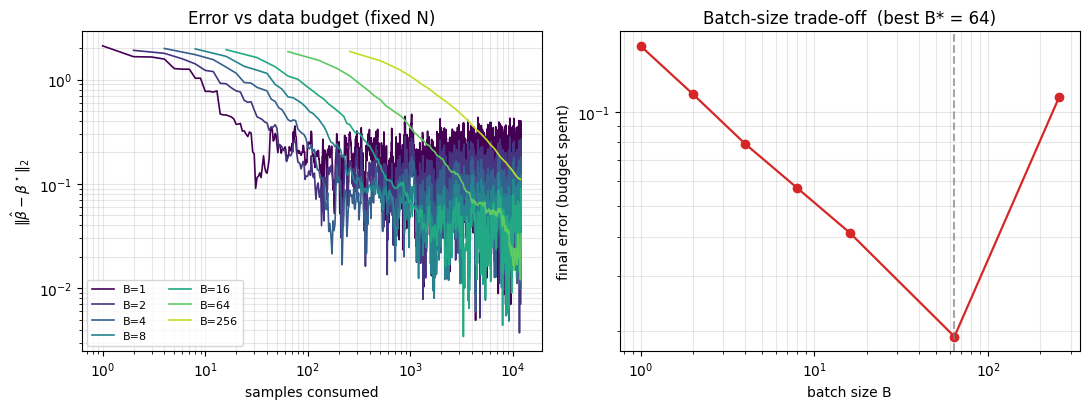

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

import matplotlib.cm as cm
cmap = cm.viridis(np.linspace(0, 0.9, len(batch_sizes)))
for c, B in zip(cmap, batch_sizes):
    consumed, err = res[B]
    ax[0].loglog(consumed, err, color=c, lw=1.2, label=f'B={B}')
ax[0].set_xlabel('samples consumed'); ax[0].set_ylabel(r'$\|\hat\beta-\beta^\star\|_2$')
ax[0].set_title('Error vs data budget (fixed N)')
ax[0].grid(True, which='both', alpha=0.3); ax[0].legend(fontsize=8, ncol=2)

Bs = np.array(batch_sizes)
finals = df['final_err'].values
ax[1].loglog(Bs, finals, 'o-', color='#d62728', lw=1.6)
Bstar = Bs[np.argmin(finals)]
ax[1].axvline(Bstar, ls='--', color='gray', alpha=0.7)
ax[1].set_xlabel('batch size B'); ax[1].set_ylabel('final error (budget spent)')
ax[1].set_title(f'Batch-size trade-off  (best B* = {Bstar})')
ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

고정예산 $N{=}12000$, $\eta{=}0.20$ 에서 측정한 최종오차는 $B{=}1$ **0.162** → $B{=}16$ 0.041 → $B^\star{=}64$ **0.019**(최소) → $B{=}256$ **0.111** 로 뚜렷한 **U자(계곡)** 를 그린다.

1. **작은 배치($B=1,2$)**: 갱신 횟수는 많지만 스텝마다 그래디언트 잡음이 커 오차 곡선이 요동치고 steady-state 바닥이 높다(0.16 부근). 잡음이 지배한다.
2. **큰 배치($B=256$)**: 스텝은 매끄럽지만 고정예산에서 갱신이 $N/B\!=\!46$ 회뿐이라 파라미터가 충분히 이동하지 못한 채 예산이 소진된다(0.111) — **수확체감**.
3. **중간 배치($B^\star=64$)**: 그래디언트 잡음 감소($\propto1/B$)와 갱신 횟수 확보 사이 균형점에서 최종오차가 최소(0.019). 우측 곡선의 계곡이 그 지점이다.
4. 좌측 로그-로그에서 큰 $B$ 곡선은 **더 오른쪽에서 끝난다**(같은 예산, 적은 갱신) — 왜 큰 배치가 '예산당' 관점에서 손해인지 시각적으로 드러난다.

> **결론**: 미니배치 크기는 *스텝 정확도*와 *스텝 개수*의 상충이며, 고정 데이터예산에서는 양 극단이 모두 나쁘고 **중간 $B^\star\!=\!64$** 가 최적이다 — 배치를 키우는 것은 잡음바닥을 낮추되 갱신 기회를 판다.

**다음 문제로**: Problem 3 은 상수 학습률 SGD 의 '수렴 못 하고 요동하는' 성질이 오히려 **비정상 추적**의 무기가 됨을 보이고, 이를 §14.6 의 **망각인자 RLS** 와 직접 대응시킨다.